In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data/weather.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (8647, 20)


In [3]:
df.head()

,year,month,day,hour,temp,temp_source,rhum,rhum_source,prcp,prcp_source,wdir,wdir_source,wspd,wspd_source,pres,pres_source,cldc,cldc_source,coco,coco_source
0,2024,1,1,0,20.8,isd_lite,84,isd_lite,0.0,metno_forecast,90,isd_lite,5.4,isd_lite,1012.7,isd_lite,0.0,metno_forecast,1.0,metno_forecast
1,2024,1,1,1,23.6,metno_forecast,69,metno_forecast,0.0,metno_forecast,68,metno_forecast,10.1,metno_forecast,1012.1,metno_forecast,0.0,metno_forecast,1.0,metno_forecast
2,2024,1,1,2,23.9,metno_forecast,65,metno_forecast,0.0,metno_forecast,66,metno_forecast,10.8,metno_forecast,1012.7,metno_forecast,7.0,metno_forecast,1.0,metno_forecast
3,2024,1,1,3,22.6,isd_lite,69,isd_lite,0.0,metno_forecast,70,isd_lite,5.4,isd_lite,1014.5,isd_lite,3.0,isd_lite,3.0,metno_forecast
4,2024,1,1,4,28.2,metno_forecast,48,metno_forecast,0.0,metno_forecast,92,metno_forecast,10.4,metno_forecast,1014.1,metno_forecast,8.0,metno_forecast,3.0,metno_forecast


In [4]:
df.columns

Index(['year', 'month', 'day', 'hour', 'temp', 'temp_source', 'rhum',
       'rhum_source', 'prcp', 'prcp_source', 'wdir', 'wdir_source', 'wspd',
       'wspd_source', 'pres', 'pres_source', 'cldc', 'cldc_source', 'coco',
       'coco_source'],
      dtype='str')

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8647 entries, 0 to 8646
Data columns (total 20 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   year         8647 non-null   int64  
 1   month        8647 non-null   int64  
 2   day          8647 non-null   int64  
 3   hour         8647 non-null   int64  
 4   temp         8647 non-null   float64
 5   temp_source  8647 non-null   str    
 6   rhum         8647 non-null   int64  
 7   rhum_source  8647 non-null   str    
 8   prcp         8577 non-null   float64
 9   prcp_source  8577 non-null   str    
 10  wdir         8647 non-null   int64  
 11  wdir_source  8647 non-null   str    
 12  wspd         8647 non-null   float64
 13  wspd_source  8647 non-null   str    
 14  pres         8647 non-null   float64
 15  pres_source  8647 non-null   str    
 16  cldc         8643 non-null   float64
 17  cldc_source  8643 non-null   str    
 18  coco         8577 non-null   float64
 19  coco_source  8577

In [6]:
missing = df.isnull().sum()

print(missing)

year            0
month           0
day             0
hour            0
temp            0
temp_source     0
rhum            0
rhum_source     0
prcp           70
prcp_source    70
wdir            0
wdir_source     0
wspd            0
wspd_source     0
pres            0
pres_source     0
cldc            4
cldc_source     4
coco           70
coco_source    70
dtype: int64


In [7]:
df["timestamp"] = pd.to_datetime(
    df[["year", "month", "day", "hour"]]
)

df.head()

,year,month,day,hour,temp,temp_source,rhum,rhum_source,prcp,prcp_source,...,wdir_source,wspd,wspd_source,pres,pres_source,cldc,cldc_source,coco,coco_source,timestamp
0,2024,1,1,0,20.8,isd_lite,84,isd_lite,0.0,metno_forecast,...,isd_lite,5.4,isd_lite,1012.7,isd_lite,0.0,metno_forecast,1.0,metno_forecast,2024-01-01 00:00:00
1,2024,1,1,1,23.6,metno_forecast,69,metno_forecast,0.0,metno_forecast,...,metno_forecast,10.1,metno_forecast,1012.1,metno_forecast,0.0,metno_forecast,1.0,metno_forecast,2024-01-01 01:00:00
2,2024,1,1,2,23.9,metno_forecast,65,metno_forecast,0.0,metno_forecast,...,metno_forecast,10.8,metno_forecast,1012.7,metno_forecast,7.0,metno_forecast,1.0,metno_forecast,2024-01-01 02:00:00
3,2024,1,1,3,22.6,isd_lite,69,isd_lite,0.0,metno_forecast,...,isd_lite,5.4,isd_lite,1014.5,isd_lite,3.0,isd_lite,3.0,metno_forecast,2024-01-01 03:00:00
4,2024,1,1,4,28.2,metno_forecast,48,metno_forecast,0.0,metno_forecast,...,metno_forecast,10.4,metno_forecast,1014.1,metno_forecast,8.0,metno_forecast,3.0,metno_forecast,2024-01-01 04:00:00


In [8]:
df = df.sort_values("timestamp").reset_index(drop=True)

In [9]:
duplicates = df["timestamp"].duplicated().sum()

print("Duplicate timestamps:", duplicates)

Duplicate timestamps: 0


In [10]:
time_diff = df["timestamp"].diff()

print(time_diff.value_counts().head(10))

timestamp
0 days 01:00:00    8577
0 days 03:00:00      68
0 days 02:00:00       1
Name: count, dtype: int64


In [11]:
df[
    ["temp", "rhum", "prcp", "wdir",
     "wspd", "pres", "cldc", "coco"]
].describe()

,temp,rhum,prcp,wdir,wspd,pres,cldc,coco
count,8647.000000,8647.000000,8577.000000,8647.000000,8647.000000,8647.000000,8643.000000,8577.000000
mean,27.319174,75.413323,0.397680,207.063028,14.767561,1009.241113,4.325581,3.987292
std,3.057020,15.468603,1.162471,117.362708,9.255813,3.291268,3.378119,3.654340
min,16.200000,18.000000,0.000000,0.000000,0.000000,998.200000,0.000000,1.000000
25%,25.400000,66.000000,0.000000,90.000000,7.600000,1006.900000,0.000000,1.000000
50%,26.800000,79.000000,0.000000,244.000000,14.000000,1009.300000,5.000000,3.000000
75%,29.000000,89.000000,0.200000,314.000000,21.200000,1011.700000,8.000000,7.000000
max,38.000000,100.000000,29.200000,360.000000,48.200000,1018.200000,8.000000,18.000000


In [12]:
df["rhum_invalid"] = (
    (df["rhum"] < 0) |
    (df["rhum"] > 100)
)

In [13]:
df["wspd_invalid"] = df["wspd"] < 0

In [14]:
df["wdir_invalid"] = (
    (df["wdir"] < 0) |
    (df["wdir"] > 360)
)

In [15]:
df["prcp_invalid"] = df["prcp"] < 0

In [16]:
df["cldc_invalid"] = (
    (df["cldc"] < 0) |
    (df["cldc"] > 8)
)

In [17]:
df["rule_anomaly"] = (
    df["rhum_invalid"] |
    df["wspd_invalid"] |
    df["wdir_invalid"] |
    df["prcp_invalid"] |
    df["cldc_invalid"]
)

In [18]:
print(df["rule_anomaly"].value_counts())

rule_anomaly
False    8647
Name: count, dtype: int64


In [19]:
weather_columns = [
    "temp",
    "rhum",
    "prcp",
    "wdir",
    "wspd",
    "pres",
    "cldc",
    "coco"
]

df["missing_anomaly"] = df[weather_columns].isnull().any(axis=1)

In [20]:
print(df["missing_anomaly"].value_counts())

missing_anomaly
False    8577
True       70
Name: count, dtype: int64


In [21]:
for col in [
    "temp_source",
    "rhum_source",
    "prcp_source",
    "wdir_source",
    "wspd_source",
    "pres_source",
    "cldc_source",
    "coco_source"
]:
    print("\n", col)
    print(df[col].value_counts(dropna=False))


 temp_source
temp_source
metno_forecast    5915
isd_lite          2732
Name: count, dtype: int64

 rhum_source
rhum_source
metno_forecast    5915
isd_lite          2732
Name: count, dtype: int64

 prcp_source
prcp_source
metno_forecast    8577
NaN                 70
Name: count, dtype: int64

 wdir_source
wdir_source
metno_forecast    5915
isd_lite          2732
Name: count, dtype: int64

 wspd_source
wspd_source
metno_forecast    5915
isd_lite          2732
Name: count, dtype: int64

 pres_source
pres_source
metno_forecast    5916
isd_lite          2731
Name: count, dtype: int64

 cldc_source
cldc_source
metno_forecast    6911
isd_lite          1732
NaN                  4
Name: count, dtype: int64

 coco_source
coco_source
metno_forecast    8577
NaN                 70
Name: count, dtype: int64


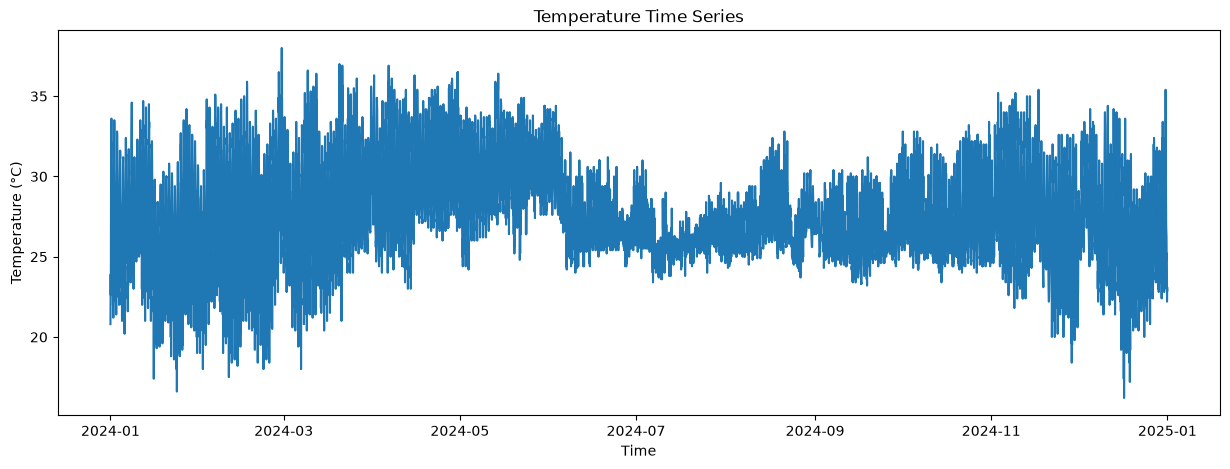

In [22]:
plt.figure(figsize=(15, 5))

plt.plot(
    df["timestamp"],
    df["temp"]
)

plt.xlabel("Time")
plt.ylabel("Temperature (°C)")
plt.title("Temperature Time Series")

plt.show()

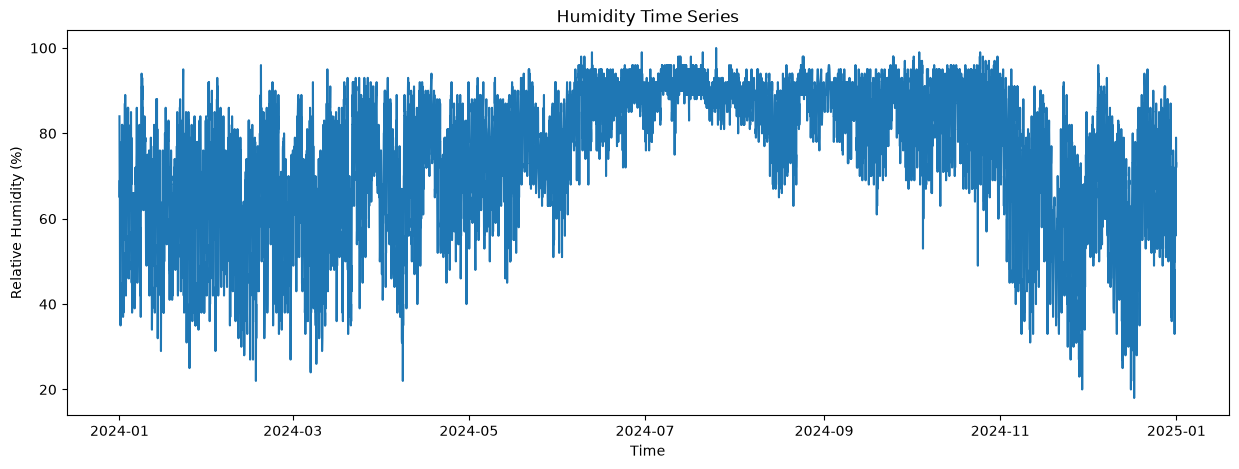

In [23]:
plt.figure(figsize=(15, 5))

plt.plot(
    df["timestamp"],
    df["rhum"]
)

plt.xlabel("Time")
plt.ylabel("Relative Humidity (%)")
plt.title("Humidity Time Series")

plt.show()

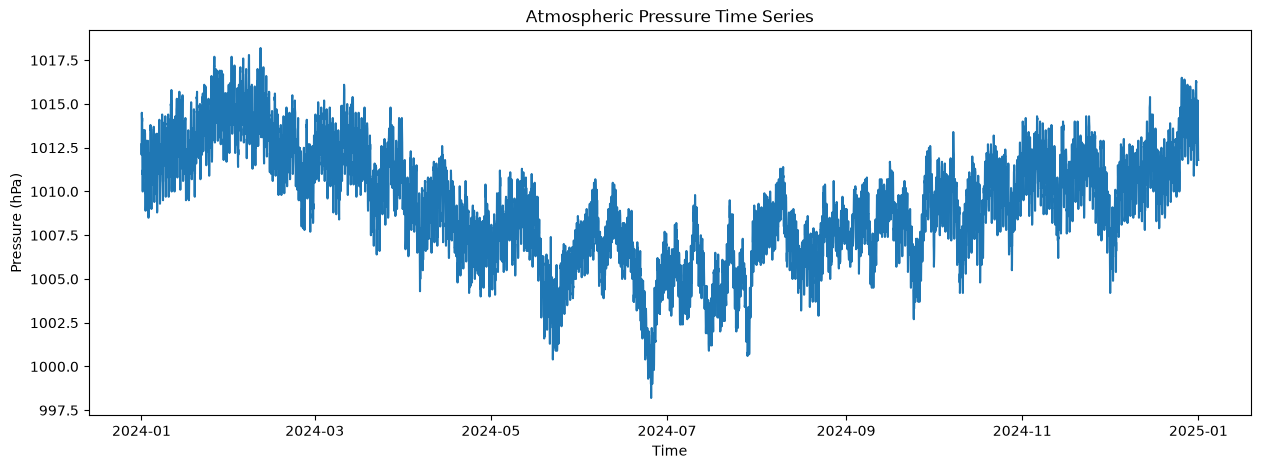

In [24]:
plt.figure(figsize=(15, 5))

plt.plot(
    df["timestamp"],
    df["pres"]
)

plt.xlabel("Time")
plt.ylabel("Pressure (hPa)")
plt.title("Atmospheric Pressure Time Series")

plt.show()

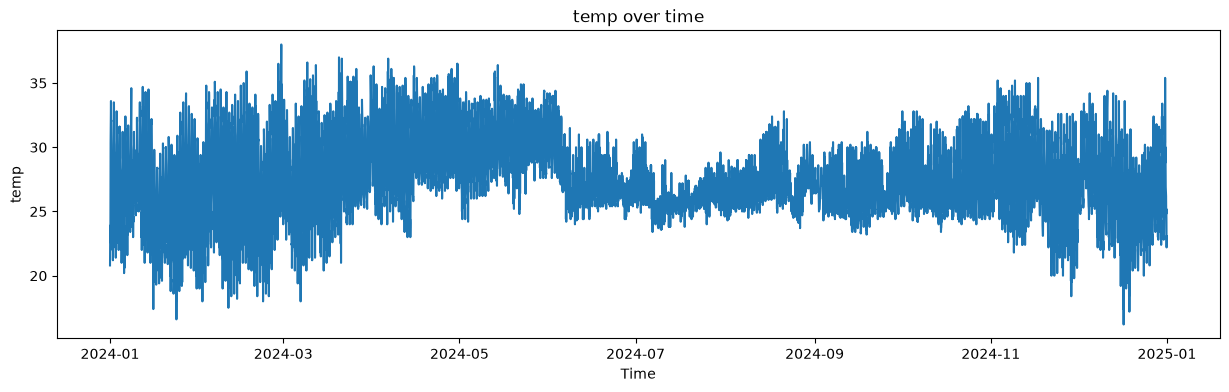

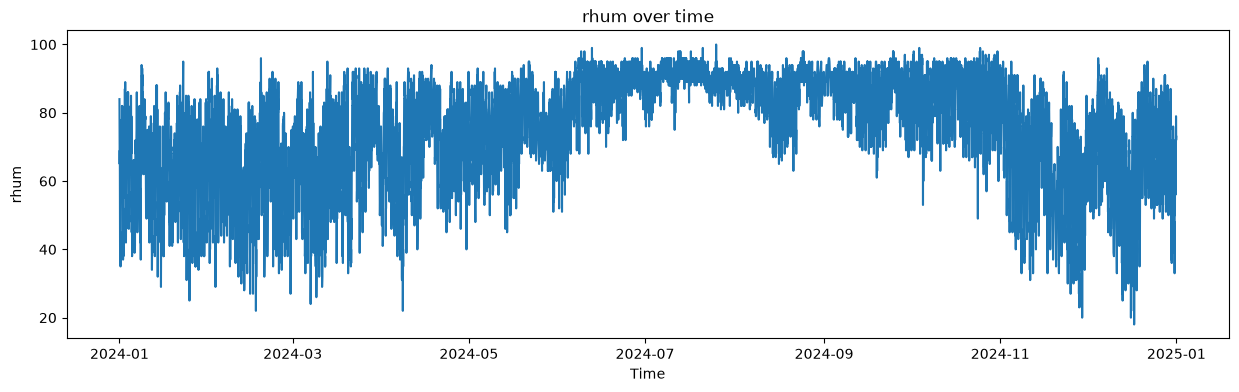

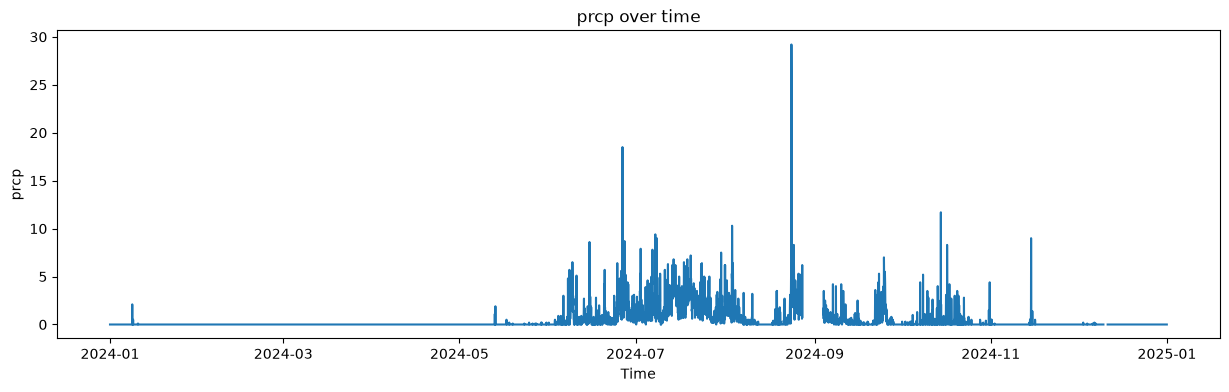

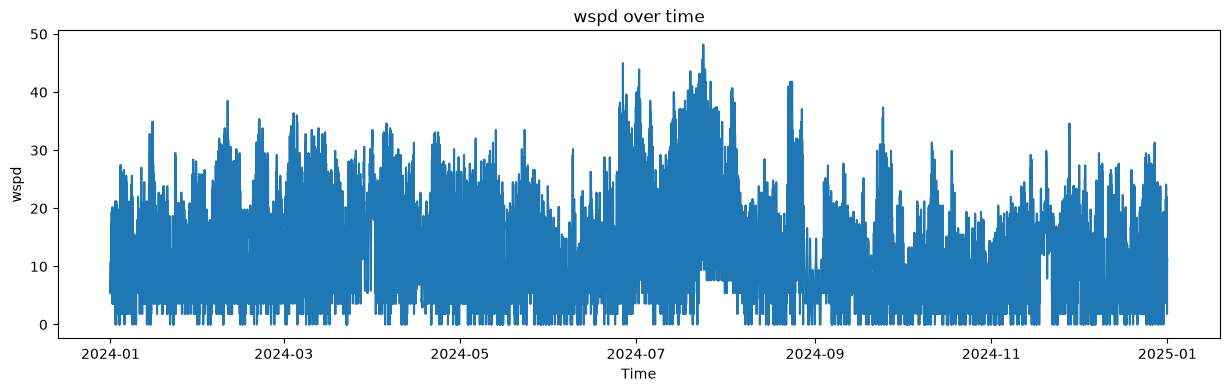

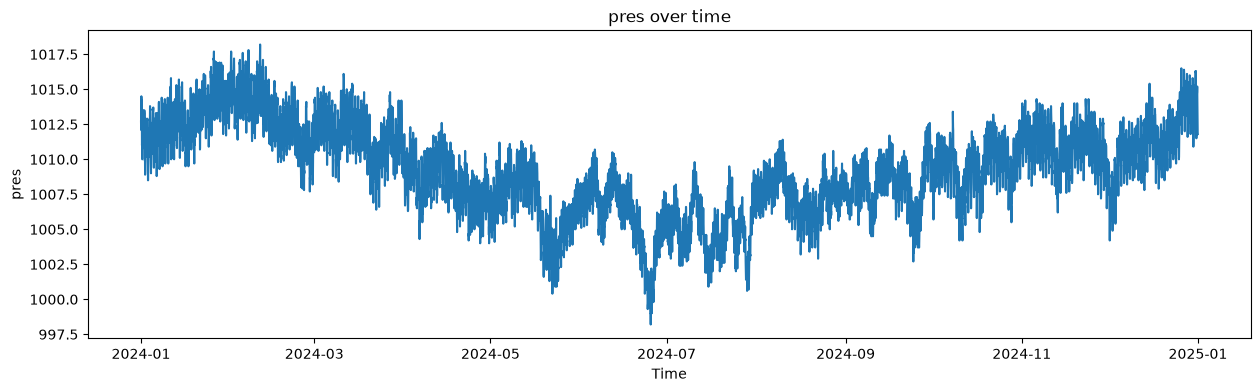

In [25]:
variables = [
    "temp",
    "rhum",
    "prcp",
    "wspd",
    "pres"
]

for col in variables:

    plt.figure(figsize=(15, 4))

    plt.plot(
        df["timestamp"],
        df[col]
    )

    plt.title(f"{col} over time")
    plt.xlabel("Time")
    plt.ylabel(col)

    plt.show()

In [26]:
df["temp_change"] = df["temp"].diff()

In [27]:
df["rhum_change"] = df["rhum"].diff()

In [28]:
df["pres_change"] = df["pres"].diff()

In [29]:
df["wspd_change"] = df["wspd"].diff()

In [30]:
df["temp_rolling_mean_24h"] = (
    df["temp"]
    .rolling(window=24)
    .mean()
)

In [31]:
df["temp_rolling_std_24h"] = (
    df["temp"]
    .rolling(window=24)
    .std()
)

In [32]:
for col in ["rhum", "pres", "wspd"]:
    
    df[f"{col}_rolling_mean_24h"] = (
        df[col].rolling(24).mean()
    )
    
    df[f"{col}_rolling_std_24h"] = (
        df[col].rolling(24).std()
    )

In [33]:
features = [
    "temp",
    "rhum",
    "prcp",
    "wdir",
    "wspd",
    "pres",
    "cldc"
]

In [34]:
ml_data = df[features].dropna().copy()

In [36]:
from sklearn.ensemble import IsolationForest

In [37]:
from sklearn.ensemble import IsolationForest

model = IsolationForest(
    n_estimators=200,
    contamination=0.02,
    random_state=42
)

model.fit(ml_data)

,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",200
,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",0.02
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary <random_state>`.",42
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",'auto'
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",1.0
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary <n_jobs>` for more details.",None
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary <warm_start>`... versionadded:: 0.21",False
Name,Type,Value
estimator_ estimator_: :class:`~sklearn.tree.ExtraTreeRegressor` instanceThe child estimator template used to create the collection offitted sub-estimators... versionadded:: 1.2 `base_estimator_` was renamed to `estimator_`.,ExtraTreeRegressor,ExtraTreeRegr...ndom_state=42)


In [38]:
ml_data["isolation_prediction"] = model.predict(
    ml_data[features]
)

In [39]:
ml_data["ml_anomaly"] = (
    ml_data["isolation_prediction"] == -1
)

In [40]:
print("Total records used:", len(ml_data))
print("Normal records:", (ml_data["ml_anomaly"] == False).sum())
print("Anomalous records:", (ml_data["ml_anomaly"] == True).sum())

Total records used: 8577
Normal records: 8405
Anomalous records: 172


In [41]:
anomalies = ml_data[ml_data["ml_anomaly"] == True]

anomalies.head(20)

,temp,rhum,prcp,wdir,wspd,pres,cldc,isolation_prediction,ml_anomaly
177,34.6,37,0.0,250,3.6,1010.5,2.0,-1,True
270,32.2,34,0.0,140,7.6,1014.1,7.0,-1,True
294,32.4,38,0.0,140,5.4,1015.3,0.0,-1,True
318,33.4,32,0.0,0,0.0,1015.2,0.0,-1,True
522,21.6,78,0.0,0,0.0,1016.1,8.0,-1,True
558,29.6,31,0.0,140,3.6,1015.2,0.0,-1,True
582,30.6,25,0.0,140,5.4,1016.6,0.0,-1,True
606,31.0,36,0.0,160,5.4,1017.7,0.0,-1,True
629,30.8,43,0.0,99,18.0,1016.8,8.0,-1,True
630,32.1,38,0.0,140,9.4,1016.9,3.0,-1,True


In [42]:
anomalies.describe()

,temp,rhum,prcp,wdir,wspd,pres,cldc,isolation_prediction
count,172.000000,172.000000,172.000000,172.000000,172.000000,172.000000,172.000000,172.0
mean,28.504070,63.470930,3.063953,166.302326,15.618023,1009.638953,5.244186,-1.0
std,4.145925,28.142999,4.841763,112.966855,13.965106,5.679896,3.409433,0.0
min,19.000000,18.000000,0.000000,0.000000,0.000000,998.200000,0.000000,-1.0
25%,25.400000,35.000000,0.000000,70.000000,3.600000,1004.600000,1.000000,-1.0
50%,27.200000,74.000000,0.000000,170.000000,10.800000,1009.900000,7.500000,-1.0
75%,32.225000,91.000000,5.700000,254.000000,28.500000,1015.200000,8.000000,-1.0
max,38.000000,98.000000,29.200000,360.000000,45.000000,1018.200000,8.000000,-1.0


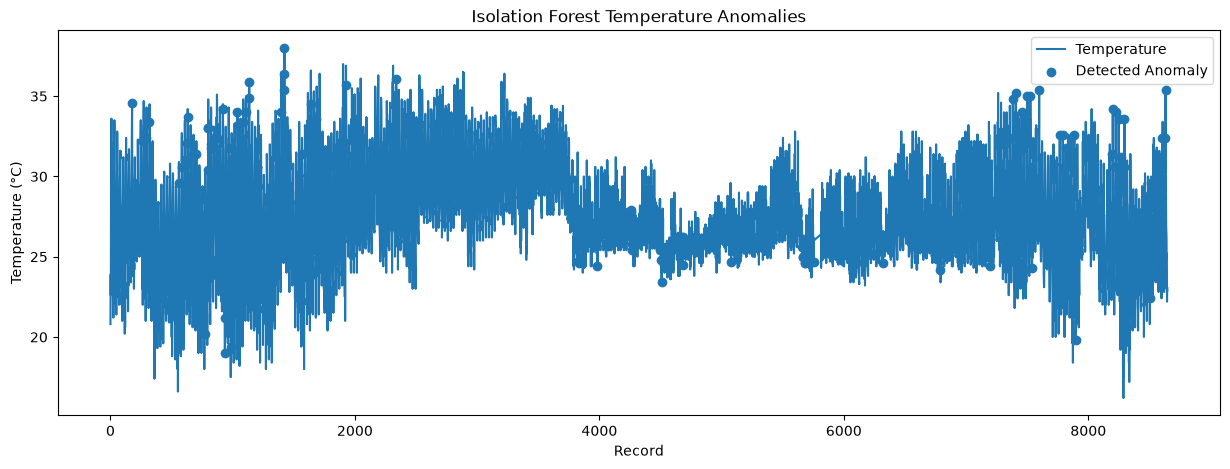

In [43]:
plt.figure(figsize=(15, 5))

plt.plot(
    ml_data.index,
    ml_data["temp"],
    label="Temperature"
)

plt.scatter(
    anomalies.index,
    anomalies["temp"],
    label="Detected Anomaly"
)

plt.xlabel("Record")
plt.ylabel("Temperature (°C)")
plt.title("Isolation Forest Temperature Anomalies")
plt.legend()
plt.show()

In [44]:
ml_data = df[["timestamp"] + features].dropna().copy()

ml_data.head()

,timestamp,temp,rhum,prcp,wdir,wspd,pres,cldc
0,2024-01-01 00:00:00,20.8,84,0.0,90,5.4,1012.7,0.0
1,2024-01-01 01:00:00,23.6,69,0.0,68,10.1,1012.1,0.0
2,2024-01-01 02:00:00,23.9,65,0.0,66,10.8,1012.7,7.0
3,2024-01-01 03:00:00,22.6,69,0.0,70,5.4,1014.5,3.0
4,2024-01-01 04:00:00,28.2,48,0.0,92,10.4,1014.1,8.0


In [45]:
model.fit(ml_data[features])

,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",200
,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",0.02
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary <random_state>`.",42
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",'auto'
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",1.0
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary <n_jobs>` for more details.",None
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary <warm_start>`... versionadded:: 0.21",False
Name,Type,Value
estimator_ estimator_: :class:`~sklearn.tree.ExtraTreeRegressor` instanceThe child estimator template used to create the collection offitted sub-estimators... versionadded:: 1.2 `base_estimator_` was renamed to `estimator_`.,ExtraTreeRegressor,ExtraTreeRegr...ndom_state=42)


In [46]:
ml_data["isolation_prediction"] = model.predict(
    ml_data[features]
)

In [47]:
ml_data["ml_anomaly"] = (
    ml_data["isolation_prediction"] == -1
)

In [48]:
anomalies = ml_data[ml_data["ml_anomaly"] == True]

anomalies.head(20)

,timestamp,temp,rhum,prcp,wdir,wspd,pres,cldc,isolation_prediction,ml_anomaly
177,2024-01-08 09:00:00,34.6,37,0.0,250,3.6,1010.5,2.0,-1,True
270,2024-01-12 06:00:00,32.2,34,0.0,140,7.6,1014.1,7.0,-1,True
294,2024-01-13 06:00:00,32.4,38,0.0,140,5.4,1015.3,0.0,-1,True
318,2024-01-14 06:00:00,33.4,32,0.0,0,0.0,1015.2,0.0,-1,True
522,2024-01-22 18:00:00,21.6,78,0.0,0,0.0,1016.1,8.0,-1,True
558,2024-01-24 06:00:00,29.6,31,0.0,140,3.6,1015.2,0.0,-1,True
582,2024-01-25 06:00:00,30.6,25,0.0,140,5.4,1016.6,0.0,-1,True
606,2024-01-26 06:00:00,31.0,36,0.0,160,5.4,1017.7,0.0,-1,True
629,2024-01-27 05:00:00,30.8,43,0.0,99,18.0,1016.8,8.0,-1,True
630,2024-01-27 06:00:00,32.1,38,0.0,140,9.4,1016.9,3.0,-1,True
